## Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import copy

## Dataset and DataLoader

In [3]:
torchvision.models.ResNet18_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [14]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load and prepare CIFAR-10 dataset (ResNet18 is typically trained on ImageNet, but we'll use CIFAR-10 for faster experimentation)
transform_train = torchvision.models.ResNet18_Weights.DEFAULT.transforms()
transform_test = torchvision.models.ResNet18_Weights.DEFAULT.transforms()

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)


Using device: cuda


## RestNet18 Model

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


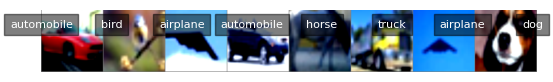

In [15]:
# Function to display a grid of sample images with labels
def imshow_with_labels(img, labels):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    # Add labels below each image
    for i in range(len(labels)):
        plt.text(i * 256 , 36, train_dataset.classes[labels[i]], ha="center", va='top', fontsize=8, color='white', bbox=dict(facecolor='black', alpha=0.5))
    plt.show()

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images with labels
imshow_with_labels(torchvision.utils.make_grid(images[:8]), labels[:8])

In [16]:
# Load pre-trained ResNet18 and adapt for CIFAR-10 (32x32 images)
model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)

# model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
# model.maxpool = nn.Identity()  # Remove the initial maxpool
# Freeze the backbone
for param in model.parameters():
    param.requires_grad = False

# Modify the final layer for CIFAR-10's 10 classes
model.fc = nn.Linear(model.fc.in_features, 10)

# Enable training for the final layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Total parameters: 11181642
Trainable parameters: 5130


## Traning and Evaluation Functions

In [18]:
# Training function, evaluation function, sparsity calculation, pruning function
def train_model(model, train_loader, epochs=3):
    """Fine-tune the model for a few epochs"""
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

def evaluate_model(model, test_loader):
    """Evaluate model accuracy"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

def calculate_sparsity(model):
    """Calculate the overall sparsity of the model"""
    
    
    total_zeros = sum((buffer == 0).sum().item() for buffer in model.buffers())
    total_params = 0
    
    for param in model.parameters():
        if param is not None:
            total_params += param.numel()
    
    if total_params == 0:
        return 0.0
    
    return (total_zeros / total_params) * 100



def prune_model(model, amount=0.5):
    """Apply global unstructured pruning to the model"""
    parameters_to_prune = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, 'weight'))
    
    # Global pruning across all layers
    print("Parameters to prune:", len(parameters_to_prune))
    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount,
    )

    return model



## Iterative Pruning Function

In [33]:
class PruningResult:
    def __init__(self, cycle,  accuracy, sparsity = None,  model = None):
        self.cycle = cycle
        self.model = model
        self.accuracy = accuracy
        self.sparsity = sparsity

    def __repr__(self):
        return (f"PruningResult(cycle={self.cycle}, accuracy={self.accuracy:.2f}%, "
                f"sparsity={self.sparsity:.2f if self.sparsity is not None else 'None'}%)")

def iterative_pruning(model, pruning_amount=0.2, max_cycles=20, early_stopping_threshold=10, original_train_epochs=10, fine_tuning_epochs=5):
    """
    Perform iterative pruning and fine-tuning cycles
    
    Args:
        model: Pre-trained model
        pruning_amount: Fraction of weights to prune in each cycle (0.2 = 20%)
        max_cycles: Maximum number of pruning cycles to perform
    
    Returns:
        performance_history: List of accuracies after each cycle
        sparsity_history: List of sparsity levels after each cycle
        pruning_results: List of PruningResult objects for each cycle
    """
    train_model(model, train_loader, epochs=original_train_epochs)
    
    # Create a copy of the original model to preserve it
    original_model = copy.deepcopy(model)
    current_model = copy.deepcopy(model)
    
    performance_history = []
    sparsity_history = []
    pruning_results = []
    
    # Evaluate original model
    original_accuracy = evaluate_model(original_model, test_loader)
    performance_history.append(original_accuracy)
    sparsity_history.append(0.0)  # 0% sparsity initially

    # pruning_results.append(PruningResult(cycle=0, model=copy.deepcopy(original_model), accuracy=original_accuracy))
    
    print(f"Original model accuracy: {original_accuracy:.2f}%")
    
    for cycle in range(1, max_cycles + 1):
        print(f"\n--- Pruning Cycle {cycle} ---")
        
        # Prune the model
        prune_model(current_model, amount=pruning_amount)
        
        # Calculate current sparsity
        current_sparsity = calculate_sparsity(current_model)
        sparsity_history.append(current_sparsity)

        
        # Fine-tune the pruned model
        print("Fine-tuning...")
        train_model(current_model, train_loader, epochs=fine_tuning_epochs)
        
        # Evaluate after fine-tuning
        accuracy = evaluate_model(current_model, test_loader)
        performance_history.append(accuracy)
        # pruning_results.append(PruningResult(cycle=cycle, model=copy.deepcopy(current_model), accuracy=accuracy, sparsity=current_sparsity))

        
        print(f"Cycle {cycle}: Accuracy = {accuracy:.2f}%, Sparsity = {current_sparsity:.2f}%")

        # Check for sharp degradation (more than early_stopping_threshold drop from original)
        if accuracy < original_accuracy - early_stopping_threshold:
            print(f"Sharp degradation detected! Stopping at cycle {cycle}")
            break
            
        # Remove pruning reparameterization to make pruning permanent
        for module in current_model.modules():
            if hasattr(module, 'weight') and hasattr(module.weight, 'mask'):
                print("removing weights")
                prune.remove(module, 'weight')

    return performance_history, sparsity_history, pruning_results

## Iterative pruning  

optimizer = SGD(lr=0.0001, momentum=0.9)


In [20]:
# Run the iterative pruning experiment
print("Starting iterative pruning experiment...")
performance_history, sparsity_history, pruning_results = iterative_pruning(model, pruning_amount=0.2, max_cycles=25, original_train_epochs=20, fine_tuning_epochs=5, early_stopping_threshold=10)



Starting iterative pruning experiment...


Epoch 1/20: 100%|██████████| 391/391 [01:45<00:00,  3.71it/s]


Epoch 1, Loss: 1.2246


Epoch 2/20: 100%|██████████| 391/391 [01:35<00:00,  4.11it/s]


Epoch 2, Loss: 0.8285


...

Epoch 3, Loss: 0.9912


Epoch 4/5: 100%|██████████| 391/391 [01:35<00:00,  4.11it/s]


Epoch 4, Loss: 0.9803


Epoch 5/5: 100%|██████████| 391/391 [01:43<00:00,  3.77it/s]


Epoch 5, Loss: 0.9710
Cycle 10: Accuracy = 66.30%, Sparsity = 89.19%
Sharp degradation detected! Stopping at cycle 10


In [21]:
# Convert sparsity_history to CPU and NumPy for plotting
def plot_performance(performance_history, sparsity_history):
    # Plot the results
    plt.figure(figsize=(10, 6))

    # Plot accuracy vs. pruning cycles
    plt.plot(range(len(performance_history)), performance_history, 'b-o', linewidth=2, markersize=6, label='Accuracy (%)')

    # Plot sparsity vs. pruning cycles
    plt.plot(range(len(sparsity_history)), sparsity_history, 'r-o', linewidth=2, markersize=6, label='Sparsity (%)')

    plt.xlabel('Pruning Cycle')
    plt.ylabel('Percentage (%)')
    plt.title('Model Performance and Sparsity vs Pruning Cycles')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


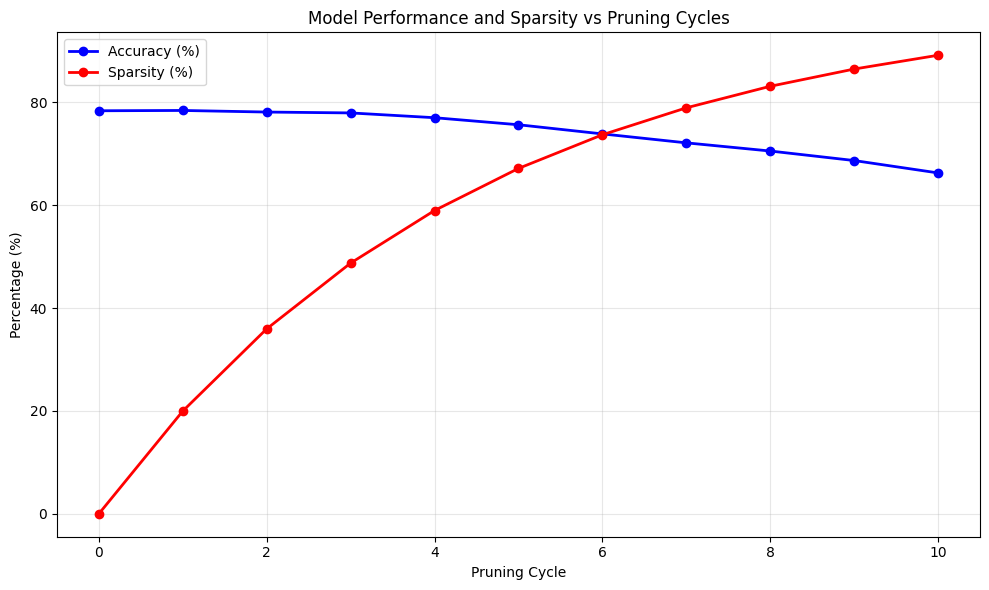

In [22]:

sparsity_history_cpu = [s.item() if isinstance(s, torch.Tensor) else s for s in sparsity_history]
plot_performance(performance_history, sparsity_history_cpu)

In [23]:

# Analysis
print("\n=== Experiment Results ===")
print(f"Original accuracy: {performance_history[0]:.2f}%")
print(f"Final accuracy: {performance_history[-1]:.2f}%")
print(f"Number of cycles before degradation: {len(performance_history) - 1}")
print(f"Final sparsity level: {sparsity_history[-1]:.2f}%")



=== Experiment Results ===
Original accuracy: 78.39%
Final accuracy: 66.30%
Number of cycles before degradation: 10
Final sparsity level: 89.19%


In [ ]:

def depth_prune(module, name, amount):
    """
    Perform depth pruning on a convolutional layer by removing entire filters.

    Args:
        module (nn.Module): The layer to prune (e.g., nn.Conv2d).
        name (str): The name of the parameter to prune (e.g., "weight").
        amount (float or int): The fraction or number of filters to prune.
    """
    # Use L2-norm pruning along the output channel dimension (dim=0)
    prune.ln_structured(module, name=name, amount=amount, n=2, dim=0)


    def prune_model(model, amount=0.5):
        """Perform depth pruning on convolutional layers."""
        for name, module in model.named_modules():
            if isinstance(module, nn.Conv2d):
                print(f"Pruning layer: {name}")
                depth_prune(module, name="weight", amount=amount)
        return model


## More Pruning

In [34]:
performance_history, sparsity_history, pruning_results = iterative_pruning(model, pruning_amount=0.2, max_cycles=40, original_train_epochs=20, fine_tuning_epochs=5, early_stopping_threshold=30)


Epoch 1/20: 100%|██████████| 391/391 [01:54<00:00,  3.41it/s]


Epoch 1, Loss: 0.5829


Epoch 2/20: 100%|██████████| 391/391 [02:02<00:00,  3.20it/s]


Epoch 2, Loss: 0.5847


Epoch 3/20: 100%|██████████| 391/391 [02:02<00:00,  3.19it/s]


...

Epoch 19, Loss: 0.5770


Epoch 20/20: 100%|██████████| 391/391 [02:03<00:00,  3.16it/s]


Epoch 20, Loss: 0.5753
Original model accuracy: 78.94%

--- Pruning Cycle 1 ---
Removing layer: conv1
Fine-tuning...


Epoch 1/5:   0%|          | 0/391 [00:00<?, ?it/s]


RuntimeError: running_mean should contain 3 elements not 64

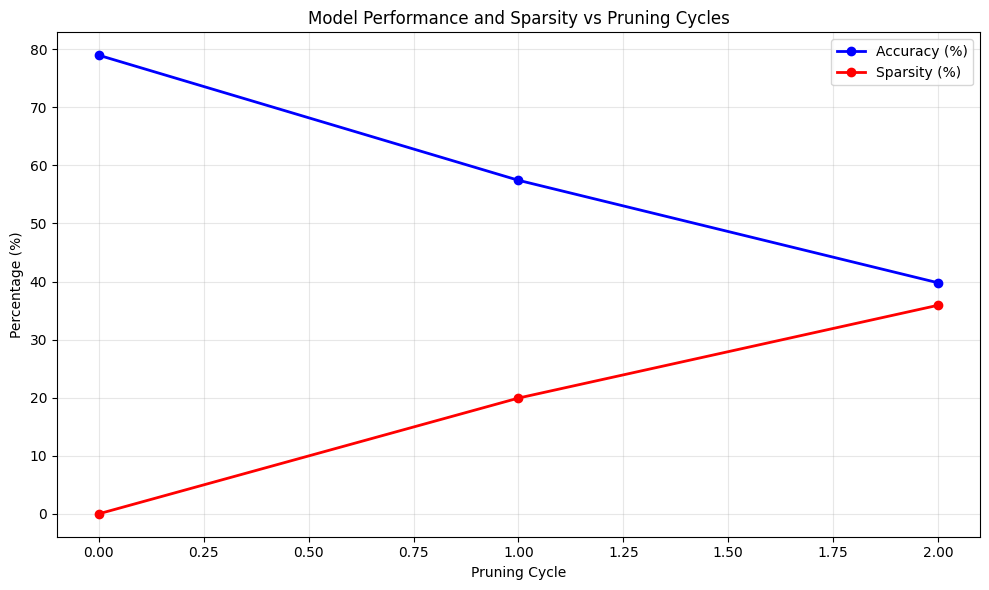

In [30]:
sparsity_history_cpu = [s.item() if isinstance(s, torch.Tensor) else s for s in sparsity_history]
plot_performance(performance_history, sparsity_history_cpu)

## Sharp Degradation  

The sharp degradation cycle is identified as the point where the model's accuracy drops by more than 10% from the original accuracy. This occurs at cycle 27, as determined in the analysis. 


In [ ]:

# Find the point of sharp degradation
sharp_degradation_threshold = 10
degradation_point = None
for i in range(1, len(performance_history)):
    if performance_history[i] < performance_history[0] - sharp_degradation_threshold:  # 10% drop threshold
        degradation_point = i
        break

if degradation_point:
    print(f"Sharp degradation occurred at cycle {degradation_point}")
else:
    print("No sharp degradation detected within the tested cycles")

Sharp degradation occurred at cycle 27


In [12]:
# Save the model to a file
model_save_path = "pruned_resnet18.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to pruned_resnet18.pth
